# **Εργασία 3**

**Καθηγητής:**  Θεοδωρακόπουλος Ηλίας

**Φοιτητής:** Ιατρού Κωνσταντίνος 58071

# **Άσκηση 1**

Κατεβάστε το seeds Dataset από τη διεύθυνση https://archive.ics.uci.edu/ml/machinelearning-databases/00236/seeds_dataset.txt . Το αρχείο περιέχει μορφολογικές μετρήσεις 210 σπόρων από τρεις ποικιλίες σιτηρών (ω1: Kama, ω2: Rosa, ω3: Canadian). Οι πρώτες 7 στήλες περιέχουν τις μετρηθείσες τιμές των μορφολογικών χαρακτηριστικών (λεπτομέρειες εδώ) και η τελευταία στήλη περιλαμβάνει την ετικέτα της ποικιλίας στην οποία ανήκει κάθε σπόρος.


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

Άρχικά εισάγονται οι βιβλιοθήκες και κάποιες συναρτήσεις που θα χρησιμοποιηθούν αργότερα στην πορεία της άσκησης.
1. Η numpy που χρησιμοποιήθηκε και στις προηγούμενες εργασίες, καθώς διευκολύνει πράξεις με πίνακες και διανύσματα λόγω της δομής ndarray που ορίζεται μέσω αυτής.
2. Το module pyplot της matplotlib το οποίο χρησιμοποιείται για την τύπωση διαγραμμάτων.
3. Η βιβλιοθήκη seaborn η οποία χρησιμοποιείται σε συνδιασμό με την matplotlib.pyplot και βοηθάει στην απεικόνιση στατιστικών δεδομένων.
4. Η συνάρτηση cdist η οποία υπολογίζει αποστάσεις αναμεσα στα ζεύγη των σημείων δύο διαφορετικών σετ δεδομένων.
5. Η κλάση KMeans η οποία σε συνδιασμό με συναρτήσεις που ορίζονται για αντικείμενα της υλοποιεί τον αλγόριθμο clustering K-Means.
6. Η συνάρτηση silhouette_score η οποία υπολογίζει και επιστρέφει το Silhouette Coefficient όλων των δειγμάτων.
7. Η συνάρτηση adjusted_rand_score που υπολογίζει την ομοιότητα μεταξύ δύο clusterings.

In [35]:
file_data = np.loadtxt('seeds_dataset.txt', encoding=None)
features = file_data[:, :-1]
class_labels = file_data[:, -1]

Στην συνέχεια εισάγεται το dataset ολόκληρο στην μεταβλητή file_data σε μορφή ndarray με 210 γραμμές (δεδομένα) και 8 στήλες (χαρακτηριστικά + ετικέτα)
και αμέσως χωρίζω τα χαρακτηριστικά από τις ετικέτες βάζοντας τα σε διαφορετικές μεταβλητές.

# Ερώτημα Α

Απεικονίστε τον πίνακα αποστάσεων των δεδομένων για Ευκλείδεια και cosine μετρικές. Ποιες κλάσεις πιστεύετε ότι είναι ευκολότερο να διαχωριστούν μεταξύ τους; Γιατί;

In [36]:
# Δημιουργία απεικόνισης του Πίνακα αποστάσεων
def plot_distance_matrix_subplot(distance_matrix, title, ax):
    sns.heatmap(distance_matrix, cmap="viridis", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Index Δείγματος")
    ax.set_ylabel("Index Δείγματος")

Εδώ για τα πλαίσια του ερωτήματος αρχικά όρισα μία συνάρτηση η οποία δημιουργεί μία απεικόνιση τύπου heatmap για να δει ο χρήστης πιο εύκολα τις αποστάσεις μεταξύ των δεδομένων και αν είναι ευδιάκριτος ο διαχωρισμός των κλάσεων και αν κάποιες κλάσεις δεν είναι ιδιαίτερα διακριτές μεταξύ τους να γίνει η ταυτοποίηση του.

Η συνάρτηση παίρνει ως όρισμα των πίνακα αποστάσεων, τον τίτλο και αν είναι σε διάγραμμα με υποδιαγράμματα το index του διαγράμματος.

Αρχικά με την βοήθεια της συνάρτησης heatmap της βιβλιοθήκης seaborn δημιουργεί μια απεικόνιση με τα δεδομένα του distance_matrix (πίνακας αποστάσεων) που δέχεται ως πρώτο argument. Το δεύτερο argument έχει να κάνει με την παλέτα χρωμάτων που θα έχει το heatmap. Επιλέχθηκε το viridis έναντι του default γιατί είναι πιο κατάλληλο για το ανθρώπινο μάτι.
Στην συνέχεια ορίζεται ο τίτλος του διαγράμματος και τα ονόματα των αξόνων.

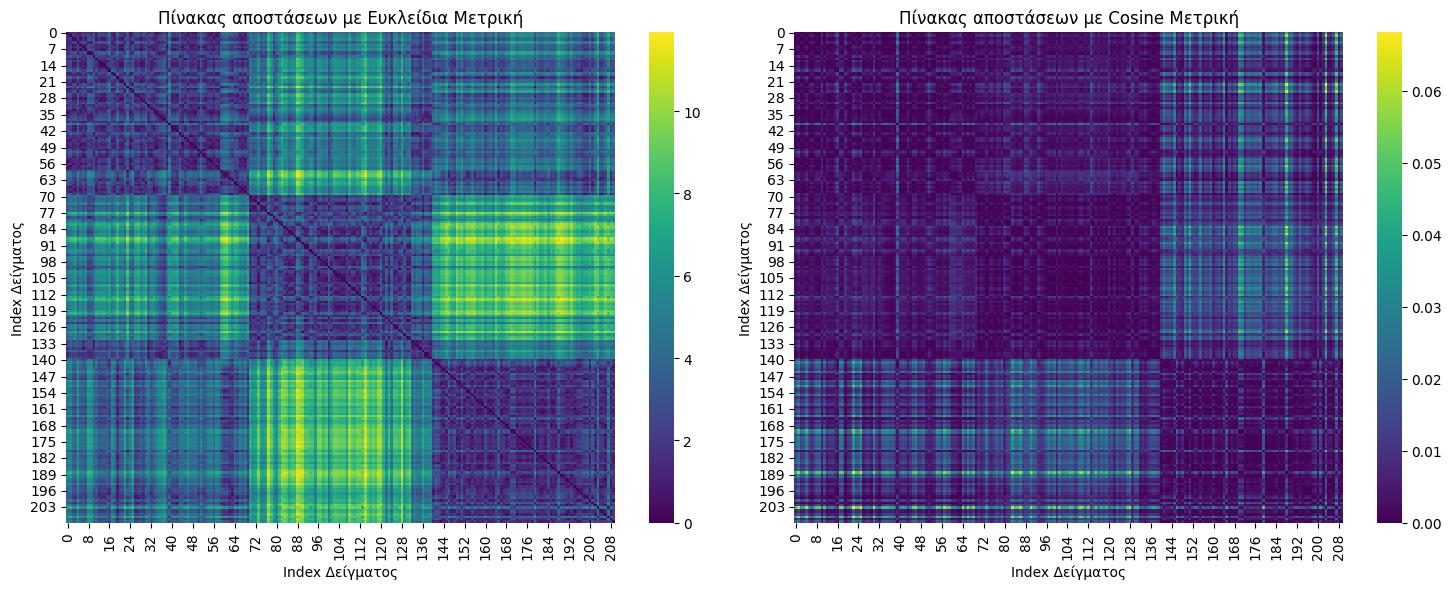

In [37]:
euclidean_distances = cdist(features, features, metric='euclidean')
cosine_distances = cdist(features, features, metric='cosine')

# Δημιουργία figure με 2 υποδιαγράμματα
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Πλοτάρω το ένα υποδιάγραμμα με τις ευκλείδια μετρική και το άλλο με cosine μετρική
plot_distance_matrix_subplot(euclidean_distances[:, :], "Πίνακας αποστάσεων με Ευκλείδια Μετρική", axes[0])
plot_distance_matrix_subplot(cosine_distances[:, :], "Πίνακας αποστάσεων με Cosine Μετρική", axes[1])

plt.tight_layout()
plt.show()

Σε αυτό το cell υπολογίζεται δύο φορές με την βοήθεια της cdist η απόσταση μεταξύ όλων των σημείων, ανά ζεύγη, μέσα στο σετ δεδομένων. Την πρώτη φορά για τον υπολογισμό των αποστάσεων χρησιμοποιείται η Ευκλείδια μετρική και ο πίνακας αποστάσεων αποθηκέυεται στην μεταβλητή euclidean_distances και την δεύτερη φορά για τον υπολογσιμό χρησιμοποιείται η cosine μετρική και ο πίνακας αποθηκέυεται στην cosine_distances.

Αμέσως μετά δημιουργείται ένα πλαίσιο για δύο υποδιαγράμματα (οριζόντια κατανεμημένα και με διαστάσεις 15x6)

Στο πρώτο υποδιάγραμμα απεικονίζω το heatmap των ευκλείδιων διαστάσεων και στο δεύτερο υποδιάγραμμα το heatmap των cosine αποστάσεων.

Στην συνέχεια χρησιμοποιείται η εντολή plt.tight_layout() για να γίνει adjust η απόσταση μεταξύ των υποδιαγραμμάτων και τέλος τα τυπώνει.

# Ερώτημα Β

Να υπολογίσετε το Silhouette Coefficient για την ομαδοποίηση των 7-διάστατων δεδομένων σε k=2,3,..10 κλάσεις με τη μέθοδο k-means και Ευκλείδεια ή squared Euclidean μετρική. Απεικονίστε το διάγραμμα του Silhouette και σχολιάστε ποιος είναι ο βέλτιστος αριθμός κλάσεων σύμφωνα με το κριτήριο αυτό.

Υπολογισμός Shilhouette Coefficient με χρήση Ευκλείδιας μετρικής (χωρίς κανονικοποίηση των δεδομένων):

Για k= 2 το Silhouette Coefficient είναι  0.525
Για k= 3 το Silhouette Coefficient είναι  0.472
Για k= 4 το Silhouette Coefficient είναι  0.384
Για k= 5 το Silhouette Coefficient είναι  0.367
Για k= 6 το Silhouette Coefficient είναι  0.345
Για k= 7 το Silhouette Coefficient είναι  0.354
Για k= 8 το Silhouette Coefficient είναι  0.346
Για k= 9 το Silhouette Coefficient είναι  0.341
Για k= 10 το Silhouette Coefficient είναι  0.345




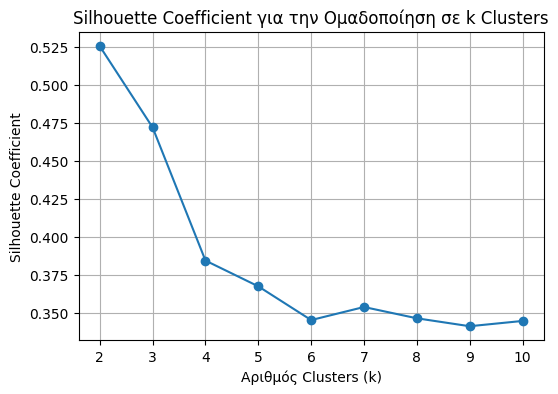

In [38]:
# Τιμές k που θα δοκιμαστούν
k_values = range(2, 11)

# Δημιουργία λίστας με τα Silhouette Coefficient ανά k
silhouette_scores = []

print('Υπολογισμός Shilhouette Coefficient με χρήση Ευκλείδιας μετρικής (χωρίς κανονικοποίηση των δεδομένων):\n')
# Υπολογισμός του Silhouette Coefficient
for i in range(len(k_values)):
    kmeans = KMeans(n_clusters=k_values[i], random_state=42, n_init=1).fit(features)
    cluster_labels = kmeans.fit_predict(features)
    silhouette_avg = silhouette_score(features, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print('Για k=', k_values[i], 'το Silhouette Coefficient είναι ', round(silhouette_avg,3))

print('\n')
# Απεικόνιση Διαγράμματος του Silhouette Coefficient συναρτήσει k
plt.figure(figsize=(6, 4))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Coefficient για την Ομαδοποίηση σε k Clusters")
plt.xlabel("Αριθμός Clusters (k)")
plt.ylabel("Silhouette Coefficient")
plt.xticks(k_values)
plt.grid(True)
plt.show()


Στην αρχή του cell ορίζεται λίστα με τιμές από 2 μέχρι 10 για τον διαφορετικό αριθμό clusters που θα δοκιμαστεί. Ακόμη ορίζουμε μία κενή λίστα που θα εισάγουμε το silhouette coefficient για κάθε διαφορετικό αριθμό των clusters.

Στην συνέχεια ορίζεται επαναληπτική διαδικασία για κάθε τιμή του k από το 2 μέχρι το 10, σύμφωνα με την λίστα k_values. Αρχικά δημιουργείται ένα αντικείμενο τύπου KMeans το οποίο είναι το μοντέλο που θα εκπαιδευτεί πάνω στα δεδομένα με τον αλγόριθμο K-Means. Η εντολή που ορίζει το αντικείμενο είναι kmeans = KMeans(n_clusters=k_values[i], random_state=42, n_init=1).fit(features), η οποία δέχεται ως όρισμα τον αριθμό των clusters, ένα random state για να είναι επαναλήψιμα τα ψευδοτυχαία αποτελέσματα και n_init, η οποία δείχνει πόσες φορές θα τρέξει ο αλγόριθμος. Ακόμη το κομμάτι .fit(features) δείχνει πανω σε ποια δεδομένα να εκπαιδευτεί ο ταξινομητής. Στην συνέχεια βλέπουμε τα αποτελέσματα του μοντέλου με την εντολή kmean.fit_predict το οποίο παίρνει τα δεδομένα και προσπαθεί να ταξινομήσει. Αμέσως μετά υπολογίζει το Shilouette Coefficient και το εισάγει στον πίνακα που τα κρατάμε για να τα απεικονίσουμε και να τα συγκρίνουμε για διαφορετικές τιμές του k.

Τέλος δημιουργώ πλαίσιο 6x4 και αποτυπώνω το διάγραμμα του Silhouette Coefficient συναρτήσει του k, δίνω τίτλο στο διάγραμμα και στους άξονες και αποτυπώνω το grid.

# Ερώτημα Γ

Να κανονικοποιηθούν τα δεδομένα ώστε κάθε χαρακτηριστικό να έχει μηδενική τιμή και μοναδιαία variance. Υπολογίσετε εκ νέου το Silhouette Coefficient στα κανονικοποιημένα δεδομένα για cosine μετρική. Απεικονίστε το νέο διάγραμμα του Silhouette. Τι παρατηρείτε?

In [39]:
# Κανονικοποίηση των χαρακτηριστικών
m = np.mean(features, axis=0)
std = np.std(features, axis=0)
features_normalized = (features - m) / std

Για την κανονικοποίηση υπολογίζω το διάνυσμα μέσης τιμής των δεδομένων και το διάνυσμα της τυπικής απόκλισης των δεδομένων.
Στη συνέχεια από τα δεδομένα αφαιρώ την μέση τιμή και διαιρώ με την τυπική απόκλιση.

Υπολογισμός Shilhouette Coefficient με χρήση cosine μετρικής (μετά από κανονικοποίηση των δεδομένων):

Για k= 2 το Silhouette Coefficient είναι  0.637
Για k= 3 το Silhouette Coefficient είναι  0.571
Για k= 4 το Silhouette Coefficient είναι  0.439
Για k= 5 το Silhouette Coefficient είναι  0.257
Για k= 6 το Silhouette Coefficient είναι  0.303
Για k= 7 το Silhouette Coefficient είναι  0.243
Για k= 8 το Silhouette Coefficient είναι  0.275
Για k= 9 το Silhouette Coefficient είναι  0.226
Για k= 10 το Silhouette Coefficient είναι  0.208




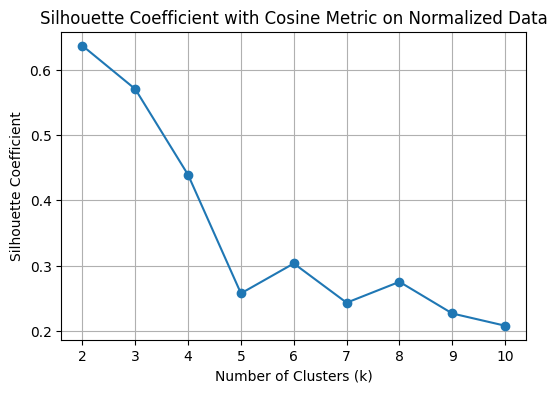

In [40]:
# Επανυπολογισμός των Silhouette Coefficient με cosine μετρική
silhouette_scores_cosine = []


print('Υπολογισμός Shilhouette Coefficient με χρήση cosine μετρικής (μετά από κανονικοποίηση των δεδομένων):\n')
for i in range(len(k_values)):
    kmeans = KMeans(n_clusters=k_values[i], random_state=42, n_init=1).fit(features)
    cluster_labels = kmeans.fit_predict(features_normalized)
    silhouette_avg_cosine = silhouette_score(features_normalized, cluster_labels, metric='cosine')
    silhouette_scores_cosine.append(silhouette_avg_cosine)
    print('Για k=', k_values[i], 'το Silhouette Coefficient είναι ', round(silhouette_avg_cosine,3))

print('\n')
# Plotting the new silhouette scores
plt.figure(figsize=(6, 4))
plt.plot(k_values, silhouette_scores_cosine, marker='o')
plt.title("Silhouette Coefficient with Cosine Metric on Normalized Data")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Coefficient")
plt.xticks(k_values)
plt.grid(True)
plt.show()




Ορίζω νέα κενή λίστα silhouette_scores_cosine στην οποία θα τοποθετήσω τις τιμές silhouette coefficient.

Μετά ορίζεται επαναληπτική διαδικασία για τις τιμές k από 2 έως και 10. Αρχικά δημιουργείται πάλι αντικείμενο τύπου KMeans το οποίο είναι το μοντέλο που θα εκεπαιδευτεί πάνω στα δεδομένα. Το μόνο που αλλάζει σε σχέση με το ερώτημα Γ είναι η εντολή silhouette_score(features_normalized, cluster_labels, metric='cosine') όπου ορίζεται στις παραμέτρους η metric ως cosine. Στο προηγούμενο ερώτημα που δεν ορίστηκε τίποτα είναι γιατί η συνάρτηση silhouette_score έχει ως default μετρική η squared Euclidean μετρική.

Η συνέχεια είναι ίδια με το προηγούμενο ερώτημα για την αποτύπωση των Silhouette Coefficient σε διάγραμμα.

# Ερώτημα Δ

Ομαδοποιείστε τα δεδομένα σε 3 κλάσεις με τη μέθοδο k-means και squared Euclidean μετρική. Υπολογίστε το Rand Index για τη σύγκριση της παραγόμενης ομαδοποίησης με τις ετικέτες του dataset. Επαναλάβετε 5 φορές (με τυχαία αρχικοποίηση κέντρων), και υπολογίστε την μέση τιμή και το variance του Rand Index.

In [48]:
# List to store Rand Index scores
rand_indices = []

# Repeating the process 5 times
for i in range(5):
    kmeans = KMeans(n_clusters=3, n_init=1, random_state=42).fit(features_normalized)  # Random state None for random initialization
    cluster_labels = kmeans.fit_predict(features_normalized)
    rand_index = adjusted_rand_score(class_labels, cluster_labels)
    rand_indices.append(rand_index)

# Calculating mean and variance of the Rand Indices
mean_rand_index = np.mean(rand_indices)
variance_rand_index = np.var(rand_indices)

print("Η μέση τιμή του Rand Index είναι", mean_rand_index)
print("Η διασπορά του Rand Index είναι", variance_rand_index)

Η μέση τιμή του Rand Index είναι 0.7732937360806309
Η διασπορά του Rand Index είναι 0.0


Αρχικοποιώ μία κενή λίστα στην οποία θα τοποθετώ τα rand indices μετά από κάθε επανάληψη.

Στην συνέχεια ορίζεται και πάλι επαναληπτική διαδικασία που θα τρέξει για 5 επαναλήψεις
Στην συνέχεια ορίζεται και πάλι αντικείμενο τύπου KMeans που θα είναι ο ταξινομητής που θα εκπαιδευτεί με τον αλγόριθμο KMeans. Περα από το γεγονός ότι ο αριθμός των clusters είναι fixed ίσος με 3 δεν υπάρχει κάποια αλλγή στον ορισμό του αντικειμένου καθώς η μετρική που χρησιμοποιείται από default για την κλάση KMeans είναι η Squared Euclidean μετρική.
Στην συνέχεια εφαρμόζουμε τον ταξινομητή πάνω στα δεδομένα (κανονικοποιημένα).

Τέλος χρησιμοποιούμε την συνάρτηση adjusted_rand_score για να συκρίνουμε τις πραγματικές ετικέτες με τις ταξινομήσεις του μοντέλου που εκπαιδεύτηκε και θα τοποθετήσουμε την τιμή rand index που παράγει η συνάρτηση στην λίστα rand_indices.

Πριν κλείσει το cell τυπώνουμε την μέση τιμή και την διασπορά των τιμών του πίνακα rand_indices.

# Ερώτημα Ε

Επαναλάβατε το (Δ) για cosine μετρική. Ποια μετρική επιτυγχάνει ομαδοποίηση πιο πιστή στις πραγματικές ομάδες των δεδομένων;

In [46]:
length = (np.sqrt(features_normalized**2).sum(axis=1))[:, None]
features_cosine = features_normalized/length

# List to store Rand Index scores
rand_indices = []

# Repeating the process 5 times
for i in range(5):
    kmeans = KMeans(n_clusters=3, n_init=1, random_state=42).fit(features_cosine)  # Random state None for random initialization
    cluster_labels = kmeans.fit_predict(features_cosine)
    rand_index = adjusted_rand_score(class_labels, cluster_labels)
    rand_indices.append(rand_index)

# Calculating mean and variance of the Rand Indices
mean_rand_index = np.mean(rand_indices)
variance_rand_index = np.var(rand_indices)

print("Η μέση τιμή του Rand Index είναι", mean_rand_index)
print("Η διασπορά του Rand Index είναι", variance_rand_index)

Η μέση τιμή του Rand Index είναι 0.679109490451972
Η διασπορά του Rand Index είναι 0.0


Η διαδικασία που χρησιμοποιήθηκε είναι ακριβώς η ίδια με πριν. Η KMeans δεν δίνει την δυνατότητα, όμως να αλλάξει η μετρική που χρησιμοποιεί.

Για να προσομοιώσουμε την μετρική cosine επεξεργαστήκαμε τα κανονικοποιημένα δεδομένα με τον εξής τρόπο:
1. Υπολογίσα το τετράγωνο κάθε στοιχείου και στην συνέχεια πήρα την τετραγωνική του ρίζα (ουσιαστικά η απόλυτη τιμή κάθε στοιχείου) και τέλος υπολόγισα το άθροισμα κάθε γραμμής. Αυτό στην ουσία είναι το norm του κάθε δείγματος.
2. Το δέυτερο μέρος της πρώτης εντολής ([:, None]) μετατρέπει τον πίνακα σε δισδιάστατο με μία στήλη ώστε να μπορεί να γίνει διαίρεση με τον πίνακα features_normalized.
3. Η διαίρεση στην συνέχεια features_normalized/length δίνει σε όλα τα στοιχεία μήκος ίσο με την μονάδα.

Με αυτό τον τρόπο παρόλο που η KMeans θα χρησιμοποιήσει Squared Euclidean μετρική στην πράξη θα προσσεγίζει σε ικανοποιήτικό βαθμό την cosine μετρική.